=== Surveying Points Management System ===


Main Menu : 
 1  Add point
 2  Remove point
 3  List all points
 4  Find point by code
 5  Sort points by code and display
 6  Search points by description keyword
 7  Distance between two points
 8  Bearing (azimuth) between two points
 9  Move a point to absolute coordinates
10  Move all points by relative shift
11  Calculate polygon area (stored order)
12  Calculate polygon perimeter (choose order)
13  Plot points (2D)
14  Plot points (3D)
15  Save points to CSV
16  Load points from CSV
17  Create simple text file (PENZD)
18  Apply affine transform from Parameters.csv
19  Line operations
20  Run Demo ( sample points )
21  Run Demo ( sample lines  )
 0  Exit

User : 20
In this case , we have 10 following Points :
Points in Demo Project :
  Point P1 : ( 0.000 ,  0.000 ,  0.000) - Color: #008080 , Pillar
  Point P2 : ( 100.000 ,  8.000 ,  10.000) - Color: #008080 , Pillar
  Point C1 : (-15.000 ,  20.000 ,  1.000) - Color: #884513 , Corner
  

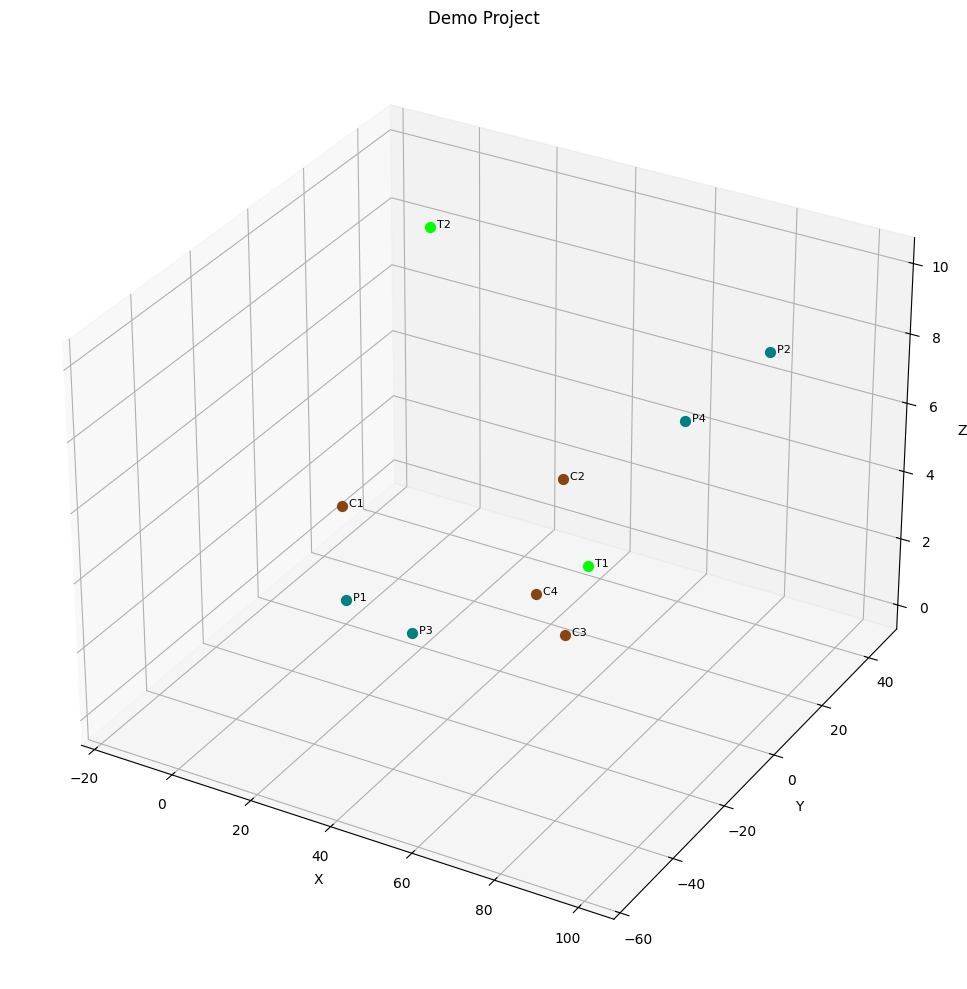

Then we will add a point like P11 with (102.1 , 14 , 11.5) as Pillar.
Point P11 added. Plotting again to see the change...
( close the plot to continue ... )


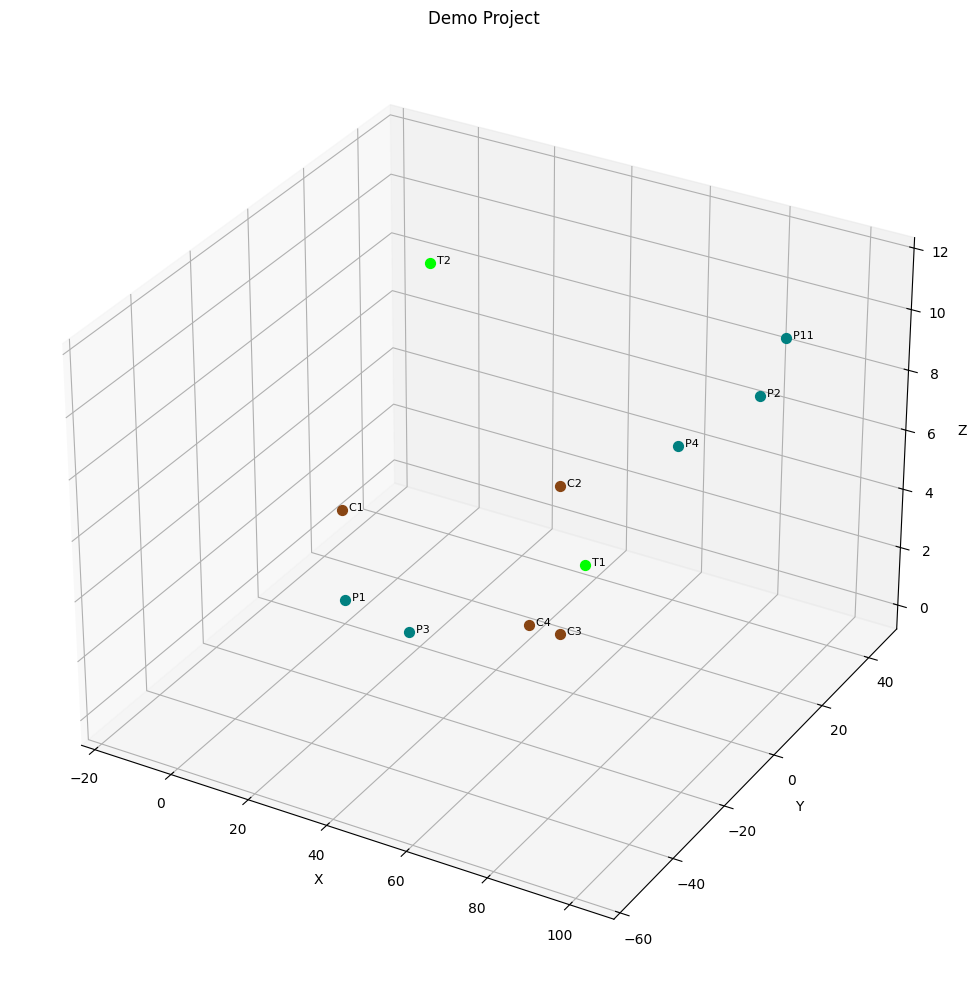

Demo points added to your project.

Main Menu : 
 1  Add point
 2  Remove point
 3  List all points
 4  Find point by code
 5  Sort points by code and display
 6  Search points by description keyword
 7  Distance between two points
 8  Bearing (azimuth) between two points
 9  Move a point to absolute coordinates
10  Move all points by relative shift
11  Calculate polygon area (stored order)
12  Calculate polygon perimeter (choose order)
13  Plot points (2D)
14  Plot points (3D)
15  Save points to CSV
16  Load points from CSV
17  Create simple text file (PENZD)
18  Apply affine transform from Parameters.csv
19  Line operations
20  Run Demo ( sample points )
21  Run Demo ( sample lines  )
 0  Exit

User : 15
Points saved to Points.csv

Main Menu : 
 1  Add point
 2  Remove point
 3  List all points
 4  Find point by code
 5  Sort points by code and display
 6  Search points by description keyword
 7  Distance between two points
 8  Bearing (azimuth) between two points
 9  Move a point to

In [ ]:
# Name : Arshya Esfandiari
# ID   : 40334201
# Task : Project about Survey Point Management
# --------------------------------------------------

# importing moduls
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Affine Transformation method
def AffineTr(Translation , Points , AnglesRad , Scales , HasZ) :
    try :
        """Apply 3D affine transform : scale , rotate , then translate."""
        for P in Points :
                IsCurrentPoint3D = True if P.Z is not None else False
                if IsCurrentPoint3D != HasZ :
                    return "ERROR! There is both 2D and 3D Points! All Points should be SAME!"
        ScaleMatrix = np.diag(Scales)
        if HasZ is True :
            # Matrix of Scales
            Coords = np.array([[P.X for P in Points] , [P.Y for P in Points] , [P.Z for P in Points]])

            # Matrices of Rotations
            Rx = np.array([[1 , 0                    , 0                    ],
                           [0 , np.cos(AnglesRad[0]) , -np.sin(AnglesRad[0])],
                           [0 , np.sin(AnglesRad[0]) ,  np.cos(AnglesRad[0])]])

            Ry = np.array([[ np.cos(AnglesRad[1]) , 0 , np.sin(AnglesRad[1])],
                           [ 0                    , 1 , 0                   ],
                           [-np.sin(AnglesRad[1]) , 0 , np.cos(AnglesRad[1])]])

            Rz = np.array([[np.cos(AnglesRad[2]) , -np.sin(AnglesRad[2]) , 0],
                           [np.sin(AnglesRad[2]) ,  np.cos(AnglesRad[2]) , 0],
                           [0                    , 0                     , 1]])

            # Calculate the Multiplication of Rotation Matrices
            RotationMatrix = Rz @ Ry @ Rx

            # Calculate and Return Result
            Result = RotationMatrix @ ScaleMatrix @ Coords + np.array(Translation).reshape(3,1)
        else :
            Coords = np.array([[P.X for P in Points] , [P.Y for P in Points]])
            Rz = np.array([[np.cos(AnglesRad) , -np.sin(AnglesRad)],
                           [np.sin(AnglesRad) ,  np.cos(AnglesRad)]])

            Result = Rz @ ScaleMatrix @ Coords + np.array(Translation).reshape(2,1)

        return Result
    except ValueError :
        return "VALUE ERROR! Invalid Dimensions or Parameter lengths!"
    except TypeError :
        return "TYPE ERROR! Incompatible Data types or Invalid Input Format!"
    except Exception as Error :
        return f"SOMETHING WENT WRONG! {Error}"

def ValidateColor(Color) :
    """Checks if the inputed color is in the list or not"""
    if Color is None :
        return "#000000"
    try :
        match Color :
            case "1" : return "#008080"    # Teal
            case "2" : return "#0000FF"    # Blue
            case "3" : return "#8B4513"    # Brown
            case "4" : return "#FFA500"    # Orange
            case "5" : return "#8A2BE2"    # Violet
            case "6" : return "#B7410E"    # Rust
            case "7" : return "#FF69B4"    # Pink
            case "8" : return "#00FF00"    # Lime
            case ""  : return "#000000"    # Black
            case _   : return "Invalid!"
    except Exception as Error :
        print(f"SOMETHING WENT WRONG! {Error}")
        return "Invalid!"

class Point : 
    # Initial method
    def __init__(self , PtID , X , Y , Z = None , Color="#000000" , Description = "") :
        self.PtID = PtID
        self.X = X
        self.Y = Y
        self.Z = Z
        self.Color = Color
        self.Description = Description

    # Calculating the distance
    def DistanceTo(self , OtherPoint) :
        """Return 2D or 3D Euclidean distance to OtherPoint."""
        try :
            # The difference between x , y , and z ( optional)
            Dx = self.X - OtherPoint.X
            Dy = self.Y - OtherPoint.Y
            # Check if it is 3D or 2D , Then Calculate distance
            if self.Z is not None and OtherPoint.Z is not None:
                Dz = self.Z - OtherPoint.Z
                Result = np.array([np.sqrt(Dx**2 + Dy**2 + Dz**2) , np.sqrt(Dx**2 + Dy**2)])
                return Result
            else :
                Result = np.sqrt(Dx**2 + Dy**2)
                return Result
        except AttributeError : 
            return "ATTRIBUTE ERROR!\nOtherPoint must be a Point object."
        except TypeError :
            return "TYPE ERROR!\nCoordinates must be numeric."
        except Exception as Error : 
            return f"SOMETHING WENT WRONG!\n{Error}"

    # Calculating the azimuth
    def BearingTo(self , OtherPoint) :
        """Return azimuth in degrees [0 , 360) from this point to OtherPoint."""
        try :
            # the differences of x and y
            Dx = OtherPoint.X - self.X
            Dy = OtherPoint.Y - self.Y
            match (Dx , Dy) :
                # Duplicated Points
                case (0 , 0) :
                    return "UNDEFINED!\nBoth points are at the same location."
                case _ :
                    Az = np.degrees(np.atan2(Dx , Dy))
                    if Az < 0 :
                        Az += 360
                    return Az
        except AttributeError :
            return "ATTRIBUTE ERROR!\nOtherPoint must be a Point object."
        except TypeError :
            return "TYPE ERROR!\nCoordinates must be numeric."
        except Exception as Error : 
            return f"SOMETHING WENT WRONG!\n{Error}"

    # return for calculations or exports
    def ToLine(self) :
        """Serialize this point to a CSV-like text line."""
        try :
            return f"{self.PtID},{self.X},{self.Y},{self.Z},{self.Color},{self.Description}"
        except Exception as Error :
            return f"SOMETHING WENT WRONG!\n{Error}"
        
    # Return for showing to user
    def __str__(self) :
        Zz = ""
        if self.Z is not None :
            Zz = f"{self.Z : .3f}"
        else :
            Zz = "Not Defined"
        return f"Point {self.PtID} : ({self.X : .3f} , {self.Y : .3f} , {Zz}) - Color: {self.Color} , {self.Description}"

class PointCloud :
    # Initial method
    def __init__(self , Name="MyPoints") :
        self.Name = Name
        self.Points = []

    # Addint point to the cloud
    def AddPoint(self , ObjP) :
        """Append a Point object to the cloud."""
        try :
            IsUnique = True
            if not isinstance(ObjP , Point) :
                print("TYPE ERROR! Invalid type of input!")
                return
            for P in self.Points :
                if P.PtID == ObjP.PtID :
                    print("ERROR! This Point ID is already in the Cloud!")
                    IsUnique = False
            if IsUnique is True :
                self.Points.append(ObjP)
        except TypeError :
            print("TYPE ERROR!\nProvided object is invalid.")
        except Exception as Error :
            print(f"SOMETHING WENT WRONG!\n{Error}")

    # Removing point from the cloud
    def RemovePoint(self , PtID) :
        """Remove point by PtID ; return True if removed , False if not found."""
        try : 
            Target = self.FindByPtID(PtID)
            if Target is not None :
                self.Points.remove(Target)
                return True                 # if Target exists
            return False                    # if not
        except ValueError :
            print("VALUE ERROR!\nTarget point not found in list.")
            return False
        except Exception as Error :
            print(f"SOMETHING WENT WRONG!\n{Error}")
            return False
    
    # Removing outside points
    def Filteration(self , MinXY , MaxXY , MinZ=None , MaxZ=None) :
        """Keep points inside bounding box ; return count of removed points."""
        try :
            # Check if there is point or not
            if not self.Points : 
                print("No points to filter.")
                return 0
            
            # Define boundaries
            MinX , MinY = MinXY[0] , MinXY[1]
            MaxX , MaxY = MaxXY[0] , MaxXY[1]
            
            # Check if Z filtering is requested
            UseZFilter = (MinZ is not None and MaxZ is not None)
            
            # The number of points
            InitialCount = len(self.Points)
            
            # Create boolean mask using list comprehension
            if UseZFilter : 
                # Filter with Z
                KeepMask = [(MinX <= P.X <= MaxX) and (MinY <= P.Y <= MaxY) and (MinZ <= P.Z <= MaxZ) for P in self.Points]
            else : 
                # Filter without Z
                KeepMask = [(MinX <= P.X <= MaxX) and (MinY <= P.Y <= MaxY) for P in self.Points]
            
            # Apply mask : keep only points where mask is True
            self.Points = [P for P , Keep in zip(self.Points , KeepMask) if Keep]
            
            # The number of removed points
            RemovedCount = InitialCount - len(self.Points)
            
            # Display the result based on Z
            if UseZFilter : 
                print(f"Filteration applied (X , Y , Z) : {RemovedCount} Points Removed - {len(self.Points)} Points Remained.")
            else : 
                print(f"Filteration applied (X , Y) : {RemovedCount} Points Removed - {len(self.Points)} Points Remained.")
            return RemovedCount
            
        except IndexError :
            print("INDEX ERROR!\nMinXY or MaxXY must contain at least 2 elements.")
            return 0
        except Exception as Error : 
            print(f"ERROR in Filteration : {Error}")
            return 0

    # Finding point based on the PtID
    def FindByPtID(self , PtID) :
        """Return the Point with matching PtID , or None if not found."""
        try :
            for P in self.Points :  # check the PtID of points
                if P.PtID == PtID :
                    return P        # if PtID have been found
            return None             # if not
        except AttributeError :
            print("ATTRIBUTE ERROR!\nPoints in list do not have PtID.")
            return None
        except Exception as Error : 
            print(f"SOMETHING WENT WRONG!\n{Error}")
            return None

    # Searching a point in PointCloud based on Description
    def SearchByDescription(self , Keyword) :
        """Return list of points whose Description contains Keyword."""
        try :
            Keyword = str(Keyword).lower()
            Results = []                              
            for P in self.Points :
                if Keyword in P.Description.lower() :
                    Results.append(P)
            return Results
        except AttributeError :
            print("ATTRIBUTE ERROR!\nPoints lack Description attribute.")
            return []
        except Exception as Error :
            print(f"SOMETHING WENT WRONG!\n{Error}")
            return []

    # Sorting Points based on PtID
    def SortByPtID(self) :
        """Sort points in place by PtID and return the sorted list."""
        try :
            def SortKey(P) :
                try :
                    ID = str(P.PtID)
                    # Extract character
                    Chars = "".join(C for C in ID if C.isalpha()).upper()
                    # Extract number
                    Nums = "".join(C for C in ID if C.isdigit())
                    NumVal = int(Nums) if Nums else 0
                    return (Chars, NumVal)
                except Exception as Error :
                    print(f"SOMETHING WENT WRONG! {Error}")
            # sorting
            self.Points.sort(key = SortKey)
            return self.Points
        except AttributeError :
            print("ATTRIBUTE ERROR!\nPoints lack PtID attribute.")
            return self.Points
        except Exception as Error :
            print(f"SOMETHING WENT WRONG!\n{Error}")
            return self.Points

    # Listing and Displaying all points
    def ListAll(self) :
        """Print all points in the cloud."""
        try :
            # Check if there are points
            if self.Points != [] :
                print(f"============================\nPoints in {self.Name} :")
                # Display points
                for P in self.Points : 
                    print(f"  {P}")
            else :                                       # if not
                print("No points in this cloud.")
        except Exception as Error : 
            print(f"SOMETHING WENT WRONG!\n{Error}")

    def ToTranslate(self , PtID , NewX , NewY , NewZ = None) : 
        """Move point PtID to absolute coordinates NewX , NewY , NewZ."""
        try :
            Target = self.FindByPtID(PtID)
            if Target is None : 
                return f"Point {PtID} not found."
            Target.X = NewX
            Target.Y = NewY
            if NewZ is not None : 
                Target.Z = NewZ
            return f"Point {PtID} moved to ({Target.X} , {Target.Y} , {Target.Z})."
        except ValueError :
            return "VALUE ERROR!\nCoordinates must be numeric values."
        except Exception as Error : 
            return f"SOMETHING WENT WRONG!\n{Error}"
    
    def ToTranslateAll(self , Dx , Dy , Dz = None) :
        """Shift all points by relative offsets Dx , Dy , and optional Dz."""
        try :
            # Add relative offsets
            for P in self.Points :
                P.X += Dx
                P.Y += Dy
                if Dz is not None and P.Z is not None :
                    P.Z += Dz

            return "All points translated successfully." 
        except TypeError :
            return "TYPE ERROR!\nOffsets must be numeric values."
        except Exception as Error :
            return f"SOMETHING WENT WRONG!\n{Error}"

    def CalculateArea(self , OrderedPtID) : 
        """Return polygon area via Shoelace formula using ordered list of PtID."""
        try : 
            match OrderedPtID :
                case [] | None :
                    return "ERROR! You must provide an ordered list of point codes."
                case _ if len(OrderedPtID) < 3 :
                    return "ERROR! Needint at least 3 Points"
                case _ :
                    OrderedPoints = []
                    for PtID in OrderedPtID :
                        Found = self.FindByPtID(PtID)
                        if Found is None :
                            return f"ERROR! Point {PtID} not found."
                        OrderedPoints.append(Found)

                    # Extract x , y  IN THE GIVEN ORDER
                    X = np.array([P.X for P in OrderedPoints])
                    Y = np.array([P.Y for P in OrderedPoints])
                    X = np.append(X , X[0])
                    Y = np.append(Y , Y[0])

                    # Calculate with Shoelace formula
                    Term1 = X[ : -1] * Y[1 : ]
                    Term2 = X[1 : ] * Y[ : -1]
                    Area = np.abs(np.sum(Term1 - Term2) / 2)

                    PathStr = " -> ".join(str(P.PtID) for P in OrderedPoints) + f" -> {OrderedPoints[0].PtID}"
                    return f"Order used : {PathStr}\nArea : {Area : .3f}"
        except IndexError : 
            return "INDEX ERROR!\nThe polygon has no vertices."
        except TypeError :
            return "TYPE ERROR!\nPoint coordinates must be numeric."
        except Exception as Error : 
            return f"SOMETHING WENT WRONG!\n{Error}"

    def CalculatePerimeter(self , OrderedPtID) : 
        """Return perimeter of polygon defined by ordered list of PtID."""
        try : 
            match OrderedPtID :
                case [] | None :
                    return "You must provide an ordered list of point codes."
                case _ if len(OrderedPtID) < 3 : 
                    return "At least 3 points are required to compute a perimeter."
                case _ : 
                    OrderedPoints = []
                    for PtID in OrderedPtID : 
                        Found = self.FindByPtID(PtID)
                        if Found is None : 
                            return f"Point {PtID} not found."
                        OrderedPoints.append(Found)

                    PathStr = " -> ".join(str(P.PtID) for P in OrderedPoints) + f" -> {OrderedPoints[0].PtID}"

                    TotalPe2D = 0.0
                    TotalPe3D = 0.0
                    HasZ = False
                    Count = len(OrderedPtID)
                    for i in range(Count) :
                        This = OrderedPoints[i]
                        That = OrderedPoints[(i+1) % Count]
                        Container = This.DistanceTo(That)
                        if isinstance(Container , np.ndarray) :
                            HasZ = True
                            TotalPe2D += Container[1]
                            TotalPe3D += Container[0]
                        elif isinstance(Container , float) :
                            TotalPe2D += Container
                        else :
                            return Container
                    if HasZ :
                        return f"Order used : {PathStr}\nHorizontal Perimeter : {TotalPe2D : .3f}\n3D Perimeter : {TotalPe3D : .3f}"
                    else :
                        return f"Order used : {PathStr}\nPerimeter : {TotalPe2D : .3f}"
        except TypeError :
            return "TYPE ERROR!\nPoint codes must be valid strings."
        except Exception as Error : 
            return f"SOMETHING WENT WRONG!\n{Error}"

    def SaveToCSV(self , FileName) :
        """Save all points to a CSV file with columns code,x,y,z,description."""
        try :
            # Prepare Dictionary for DataFrame
            DataFrame = pd.DataFrame({
                "ptid" : [P.PtID for P in self.Points],
                "x"    : [P.X for P in self.Points],
                "y"    : [P.Y for P in self.Points],
                "z"    : [P.Z for P in self.Points],
                "description" : [P.Description for P in self.Points],
            })
            # Set DataFrame
            if FileName[-4:] != ".csv" :
                FileName = FileName + ".csv"
            DataFrame.to_csv(f"{FileName}" , index=False)
            print(f"Points saved to {FileName}")
        except FileNotFoundError :
            print(f"FILE NOT FOUND!\nPath to {FileName} is invalid.")
        except Exception as Error :
            print(f"SOMETHING WENT WRONG!\n{Error}")

    def LoadFromCSV(self , FileName) :
        """Load points from a CSV file ; replaces current cloud contents."""
        try :
            # Read CSV file
            if FileName[-4:] != ".csv" :
                FileName = FileName + ".csv"
            DataFrame = pd.read_csv(FileName)
            self.Points = []
            # Fill Points list up
            for _ , Row in DataFrame.iterrows() : 
                Container = Row.get("z" , None)
                self.AddPoint(Point(
                    Row["ptid"],                                                    # Point ID
                    float(Row["x"]),                                                # X
                    float(Row["y"]),                                                # Y
                    float(Container) if pd.notna(Container) else None,              # Z - Default : None
                    str(Row.get("description" , ""))                                # Default : Des = ""
                ))
            print(f"Loaded {len(self.Points)} points from {FileName}")
        except FileNotFoundError : 
            print(f"FILE NOT FOUND!\n{FileName} does not exist.")
        except KeyError : 
            print("INVALID CSV FORMAT!\nRequired PENZD format : ptid,x,y,z,description")
        except Exception as Error : 
            print(f"SOMETHING WENT WRONG!\n{Error}")

    def PlotPoints(self , HasZ) :
        """3D or 2D scatter plot"""
        try :
            # Check if there are Points
            if not self.Points :
                print("No points to plot.")
                return
            
            # Plot Scatter nodes
            Figure = plt.figure(figsize = (10 , 10))
            Axis = Figure.add_subplot(111 , projection = "3d") if HasZ is True else Figure.add_subplot(111)
            for ObjP in self.Points :
                if ObjP.Z is None and HasZ is True :
                    return "ERROR! Mixed 2d and 3d points!"
                
                # Get Color
                if hasattr(ObjP , "Color") and ObjP.Color :
                    ColorName = ObjP.Color
                else :
                    FirstLetter = ObjP.Description[ : 1].upper() if ObjP.Description else ""
                    match FirstLetter :
                        case "P" :
                            ColorName = "blue"
                        case "C" :
                            ColorName = "green"
                        case "G" :
                            ColorName = "orange"
                        case _ :
                            ColorName = "red"
                
                # Plot specs for point
                if HasZ is True :
                    Axis.scatter(ObjP.X , ObjP.Y , ObjP.Z , color=ColorName , s=50)
                    Axis.text(ObjP.X , ObjP.Y , ObjP.Z , f"  {ObjP.PtID}" , fontsize=8)
                    Axis.set_zlabel("Z")
                else :
                    Axis.scatter(ObjP.X , ObjP.Y , color=ColorName , s=50)
                    Axis.text(ObjP.X , ObjP.Y , f"  {ObjP.PtID}" , fontsize=8)
            # Plot specs
            Axis.set_xlabel("X")
            Axis.set_ylabel("Y")
            Axis.set_title(self.Name)
            plt.tight_layout()
            plt.show()
        except KeyError :
            print("KEY ERROR!\nInvalid 3D plot styling configuration.")
        except Exception as Error :
            print(f"SOMETHING WENT WRONG!\n{Error}")

    def ApplyAffine(self , HasZ , FileName = "Parameters.csv") : 
        """Read transform parameters from CSV and apply affine transform to all points."""
        try : 
            if FileName[-4:] != ".csv" :
                FileName = FileName + ".csv"
            if not self.Points : 
                return "No points to transform."
            if HasZ is True :
                DataFile = pd.read_csv(FileName, usecols=["PtID", "x", "y", "z"])
                Translation = DataFile[DataFile["PtID"] == "translation"][["x" , "y" , "z"]].values[0]
                AnglesDeg = DataFile[DataFile["PtID"] == "rotation"][["x" , "y" , "z"]].values[0]
                Scales = DataFile[DataFile["PtID"] == "scale"][["x" , "y" , "z"]].values[0]
            else :
                DataFile = pd.read_csv(FileName, usecols=["PtID", "x", "y"])
                Translation = DataFile[DataFile["PtID"] == "translation"][["x" , "y"]].values[0]
                AnglesDeg = DataFile[DataFile["PtID"] == "rotation"][["x"]].values[0]
                Scales = DataFile[DataFile["PtID"] == "scale"][["x" , "y"]].values[0]

            # Apply affine transformation
            Transformed = AffineTr(Translation , self.Points , np.radians(AnglesDeg) , Scales , HasZ)
            
            # Return the error log if it has error
            if isinstance(Transformed, str) :
                return Transformed
            
            # Update transformed coordinates
            for Index , ObjP in enumerate(self.Points) : 
                ObjP.X = Transformed[0 , Index]
                ObjP.Y = Transformed[1 , Index]
                if HasZ is True :
                    ObjP.Z = Transformed[2 , Index]

            return "Affine transform applied to all points."
        except FileNotFoundError : 
            return f"FILE NOT FOUND!\n{FileName} was not found."
        except KeyError : 
            return "INVALID CSV FORMAT!\nRequired columns : PtID,x,y,z"
        except Exception as Error : 
            return f"SOMETHING WENT WRONG!\n{Error}"

class Line :
    # Initial method
    def __init__(self , PtID , StartPoint , EndPoint , Color="black" , Description="") : 
        self.PtID = PtID
        self.StartPoint = StartPoint
        self.EndPoint = EndPoint
        self.Color = Color
        self.Description = Description

    # Calculate the Length of Line
    def Length(self) :
        """Return Euclidean distance between StartPoint and EndPoint."""
        try :
            Container = self.StartPoint.DistanceTo(self.EndPoint)
            if isinstance(Container , np.ndarray) :
                return f"3D Len : {Container[0] : .3f}\n2D Len : {Container[1] : .3f}"
            elif isinstance(Container , float) :
                return f"2D Len : {Container : .3f}"
            else :
                return Container
        except AttributeError :
            return "ATTRIBUTE ERROR!\nStartPoint or EndPoint are not valid Point objects."
        except Exception as Error :
            return f"SOMETHING WENT WRONG!\n{Error}"
    
    # Calculate the Azimuth of Line
    def Azimuth(self) :
        """Azimuth of the line , in degrees [0 , 360) , measured from Start to End."""
        try :
            return self.StartPoint.BearingTo(self.EndPoint)
        except AttributeError :
            return "ATTRIBUTE ERROR!\nStartPoint or EndPoint are not valid Point objects."
        except Exception as Error : 
            return f"SOMETHING WENT WRONG!\n{Error}"


    def PlotLines(LinesList, HasZ) :
        """Plots all lines 2d or 3d"""
        try :
            if not LinesList :
                return "No Lines to plot"

            if HasZ is True :
                for L in LinesList :
                    if L.StartPoint is None or L.EndPoint is None :
                        return "ERROR! There are 2D Line(s)!"
            
            # Create figure
            Figure = plt.figure(figsize=(8, 8))
            Axis = Figure.add_subplot(111) if HasZ is False else Figure.add_subplot(111 , projection = "3d")

            for L in LinesList :
                # Coordinates
                XVals = [L.StartPoint.X, L.EndPoint.X]
                YVals = [L.StartPoint.Y, L.EndPoint.Y]
                ZVals = [L.StartPoint.Z, L.EndPoint.Z]

                if HasZ is False:
                   Axis.plot(XVals, YVals, color = L.Color, linewidth=2, label=f"Line {L.PtID}")
                   Axis.scatter(XVals, YVals, color = L.Color, s=80, zorder=5)
                   Axis.text(L.StartPoint.X, L.StartPoint.Y, f"  {L.StartPoint.PtID}", fontsize=9)
                   Axis.text(L.EndPoint.X,   L.EndPoint.Y,   f"  {L.EndPoint.PtID}",   fontsize=9)
                else :
                   Axis.plot(XVals, YVals, ZVals, color = L.Color, linewidth=2, label=f"Line {L.PtID}")
                   Axis.scatter(XVals, YVals, ZVals, color = L.Color, s=80)
                   Axis.text(L.StartPoint.X, L.StartPoint.Y, L.StartPoint.Z, f"  {L.StartPoint.PtID}", fontsize=9)
                   Axis.text(L.EndPoint.X,   L.EndPoint.Y,   L.EndPoint.Z,   f"  {L.EndPoint.PtID}",   fontsize=9)
                   Axis.set_zlabel("Z")

            Axis.set_xlabel("X")
            Axis.set_ylabel("Y")
            Axis.set_title(f"LInes Scatter Plot")
            Axis.legend()
            plt.tight_layout()
            plt.show()
        except AttributeError:
            print("ATTRIBUTE ERROR!\nStartPoint or EndPoint are not valid Point objects.")
        except Exception as Error:
            print(f"SOMETHING WENT WRONG!\n{Error}")

    # Return for showing to user
    def __str__(self) :
        return (f"Line {self.PtID} [{self.Color}] : "
                f"{self.StartPoint.PtID} -> {self.EndPoint.PtID} - {self.Description}")

# Create simple txt with point data 
def SaveToTXT(Cloud , FileName = "SimplePoints.txt") : 
    """Creates a txt file and saves the data in it."""
    try : 
        if FileName[-4:] != ".txt" :
            FileName = FileName + ".txt"
        with open(FileName , "w" , encoding = "utf-8") as File :
            File.write("ptid,x,y,z,description\n") 
            for ObjP in Cloud.Points : 
                File.write(f"{ObjP.PtID},{ObjP.X},{ObjP.Y},{ObjP.Z},{ObjP.Description}\n")
        print(f"TXT file created : {FileName}")
    except Exception as Error : 
        print(f"SOMETHING WENT WRONG!\n{Error}")

def MainMenu() :
    """The main menu of program which can choose options"""
    try :
        print("=== Surveying Points Management System ===\n")
        Cloud = PointCloud("My Project")
        LinesList = []

        while True : 
            print("\nMain Menu : ")
            print(" 1  Add point")
            print(" 2  Remove point")
            print(" 3  List all points")
            print(" 4  Find point by code")
            print(" 5  Sort points by code and display")
            print(" 6  Search points by description keyword")
            print(" 7  Distance between two points")
            print(" 8  Bearing (azimuth) between two points")
            print(" 9  Move a point to absolute coordinates")
            print("10  Move all points by relative shift")
            print("11  Calculate polygon area (stored order)")
            print("12  Calculate polygon perimeter (choose order)")
            print("13  Plot points (2D)")
            print("14  Plot points (3D)")
            print("15  Save points to CSV")
            print("16  Load points from CSV")
            print("17  Create simple text file (PENZD)")
            print("18  Apply affine transform from Parameters.csv")
            print("19  Line operations")
            print("20  Run Demo ( sample points )")
            print("21  Run Demo ( sample lines  )")
            print(" 0  Exit\n")

            Choice = input("\n>> ")
            match Choice :
                case "1" :
                    print(f"User : {Choice}")
                    while True :
                        PtID = input("PtID : ")
                        X = float(input("X : "))
                        Y = float(input("Y : "))
                        Container = input("Z ( Press Enter to skip ) : ")
                        if Container.strip() :
                            Z = float(Container)
                        else :
                            Z = None
                        while True :
                            print("Color :\n1  Teal\t\t2  Blue\t\t3  Brown\t4  Orange\n5  Violet\t6  Dark Orange\t7  Pink\t\t8  Lime\n\ndefault value : black ( press Enter )") # Dark Orange == Rust
                            UserChoice = input(">> ")
                            Color = ValidateColor(UserChoice)
                            if Color != "Invalid!" :
                                print(f"Color : {Color}")
                                break
                            else :
                                print("ERROR! You should choose one of colors")
                        Description = input("Description : ")
                        Cloud.AddPoint(Point(PtID , X , Y , Z , Color , Description))
                        print(f"Point {PtID} added.")
                        while True :
                            UserChoice = input("Do you want to add more ? (y/n)\n>> ").lower()
                            if UserChoice == "y" or UserChoice == "n" :
                                break
                            else :
                                print("ERROR! just yes or no ?")
                        if UserChoice == "n" :
                            PlotAfterChange(Cloud)
                            break

                case "2" :
                    print(f"User : {Choice}")
                    while True :
                        PtID = input("PtID to remove : ")
                        print(f"Point {PtID} has been removed successfully!" if Cloud.RemovePoint(PtID) else "Point not found.")
                        while True :
                            UserChoice = input("Do you want to remove more ? (y/n)\n>> ").lower()
                            if UserChoice == "y" or UserChoice == "n" :
                                break
                            else :
                                print("ERROR! just yes or no ?")
                        if UserChoice == "n" :
                            PlotAfterChange(Cloud)
                            break

                case "3" :
                    print(f"User : {Choice}")
                    Cloud.ListAll()

                case "4" : 
                    print(f"User : {Choice}")
                    PtID = input("PtID : ")
                    Found = Cloud.FindByPtID(PtID)
                    print(f"The Point has been found :\n{Found}" if Found else "Point not found.")

                case "5" : 
                    print(f"User : {Choice}")
                    print("Sorted List :")
                    Cloud.SortByPtID()
                    Cloud.ListAll()

                case "6" : 
                    print(f"User : {Choice}")
                    KeyWord = input("Description keyword : ")
                    Results = Cloud.SearchByDescription(KeyWord)
                    match Results : 
                        case [] : 
                            print("No matches found.")
                        case _ :
                            print(f"The Points with \"{KeyWord}\" keyword :")
                            for P in Results : 
                                print(f"  {P}")

                case "7" : 
                    print(f"User : {Choice}")
                    Code1 = input("First point code : ")
                    Code2 = input("Second point code : ")
                    P1 = Cloud.FindByPtID(Code1)
                    P2 = Cloud.FindByPtID(Code2)
                    if P1 and P2 : 
                        print(f"From {P1} to {P2} :")
                        Result = P1.DistanceTo(P2)
                        if isinstance(Result , np.ndarray) :
                            print(f"3D distance : {Result[0] : .3f}\nHorizontal distance : {Result[1] : .3f}")
                        else :
                            print(f"Horizontal distance : {Result : .3f}")
                    else : 
                        print("One or both points not found.")

                case "8" :
                    print(f"User : {Choice}")
                    Code1 = input("From point code : ")
                    Code2 = input("To point code ( default : Origin [0,0] ) : ")
                    P1 = Cloud.FindByPtID(Code1) or Point("Origin" , 0 , 0 , 0)
                    P2 = Cloud.FindByPtID(Code2) or Point("Origin" , 0 , 0 , 0)
                    if P1 and P2 :
                        print(f"From {P1} to {P2} :")
                        print(f"Bearing : {P1.BearingTo(P2)}")
                    else : 
                        print("One or both points not found.")

                case "9" :
                    print(f"User : {Choice}")
                    while True :
                        PtID = input("PtID of point to move : ")
                        NewX = float(input("New X : "))
                        NewY = float(input("New Y : "))
                        NewZ = input("New Z (leave empty to keep current) : ")
                        NewZ = float(NewZ) if NewZ else None
                        print(Cloud.ToTranslate(PtID , NewX , NewY , NewZ))
                        while True :
                            UserChoice = input("Do you want to change more Points ? (y/n)\n>> ").lower()
                            if UserChoice == "y" or UserChoice == "n" :
                                break
                            else :
                                print("ERROR! just yes or no ?")
                        if UserChoice == "n" :
                            PlotAfterChange(Cloud)
                            break
                        
                case "10" :
                    print(f"User : {Choice}")
                    try :
                        Dx = float(input("X Axis Shift :\n>> "))
                        Dy = float(input("Y Axis Shift :\n>> "))
                        Dz = input("Z Axis Shift (press Enter if points are 2D):\n>> ")
                        Dz = float(Dz) if Dz.strip() else None
                        Cloud.ToTranslateAll(Dx , Dy , Dz)
                        PlotAfterChange(Cloud)
                    except ValueError :
                        print("ERROR! Invalid numbers.")

                case "11" : 
                    print(f"User : {Choice}")
                    CodesInput = input("Enter point codes in order , separated by commas : ")
                    OrderedPtID = [C.strip() for C in CodesInput.split(",") if C.strip()]
                    print(Cloud.CalculateArea(OrderedPtID))

                case "12" : 
                    print(f"User : {Choice}")
                    CodesInput = input("Enter point codes in order , separated by commas : ")
                    OrderedPtID = [C.strip() for C in CodesInput.split(",") if C.strip()]
                    print(Cloud.CalculatePerimeter(OrderedPtID))

                case "13" : 
                    print(f"User : {Choice}")
                    Cloud.PlotPoints(False)

                case "14" : 
                    print(f"User : {Choice}")
                    Cloud.PlotPoints(True)

                case "15" : 
                    print(f"User : {Choice}")
                    FileName = input("File name (e.g. points.csv) : ")
                    Cloud.SaveToCSV(FileName)

                case "16" : 
                    print(f"User : {Choice}")
                    FileName = input("File name ( PENZD format ) : ")
                    Cloud.LoadFromCSV(FileName)

                case "17" : 
                    print(f"User : {Choice}")
                    FileName = input("File name (default SimplePoints.txt) : ") or "SimplePoints.txt"
                    SaveToTXT(Cloud , FileName)

                case "18" :
                    print(f"User : {Choice}")
                    while True :
                        UserChoice = input("Is your Points dimmension 3D ? (y/n)\n>> ")
                        if UserChoice == "y" or UserChoice == "n" :
                            break
                        else :
                            print("ERROR! just yes or no ?")

                    HasZ = True if UserChoice == "y" else False
                    FileName = input("Please insert your file name ( enter if the file name is Parameters.csv ) :\n>> ") or "Parameters.csv"
                    print(Cloud.ApplyAffine(HasZ , FileName))

                case "19" : 
                    print(f"User : {Choice}")
                    LineSubMenu(Cloud , LinesList)

                case "20" :
                    print(f"User : {Choice}")
                    # Create new cloud
                    DemoCloud = PointCloud("Demo Project")
                    # Add 10 sample points with different categories
                    DemoCloud.AddPoint(Point("P1" , 0 , 0 , 0 , "#008080" , "Pillar"))
                    DemoCloud.AddPoint(Point("P2" , 100 , 8 , 10 , "#008080" , "Pillar"))
                    DemoCloud.AddPoint(Point("C1" , -15 , 20 , 1 , "#884513" , "Corner"))
                    DemoCloud.AddPoint(Point("C2" , 30 , 40 , 2 , "#884513" , "Corner"))
                    DemoCloud.AddPoint(Point("C3" , 50 , 10 , 0 , "#884513" , "Corner"))
                    DemoCloud.AddPoint(Point("P3" , 20 , -4 , 0 , "#008080" , "Pillar"))
                    DemoCloud.AddPoint(Point("P4" , 70 , 25 , 6 , "#008080" , "Pillar"))
                    DemoCloud.AddPoint(Point("C4" , 85 , -55 , 7 , "#884513" , "Corner"))
                    DemoCloud.AddPoint(Point("T1" , 40 , 35 , 0 , "#00ff00" , "Tree"))
                    DemoCloud.AddPoint(Point("T2" , -8 , 45 , 8 , "#00ff00" , "Tree"))
                    HasZ = False
                    for P in DemoCloud.Points :
                        if P.Z is not None :
                            HasZ = True
                            break
                    print("In this case , we have 10 following Points :")
                    DemoCloud.ListAll()
                    print("\nAnd the plot will open : ( close the plot to continue ... )")
                    DemoCloud.PlotPoints(HasZ)  # Plot initial points
                    # Add new point P11
                    print("Then we will add a point like P11 with (102.1 , 14 , 11.5) as Pillar.")
                    DemoCloud.AddPoint(Point("P11", 102.1 , 14 , 11.5 , "#008080" , "Pillar"))
                    print("Point P11 added. Plotting again to see the change...\n( close the plot to continue ... )")
                    DemoCloud.PlotPoints(HasZ)  # Plot updated points
                    while True :
                        UserChoice = input("Do you want to keep points ? (y/n)\n>> ").lower()
                        if UserChoice == "y" or UserChoice == "n" :
                            if UserChoice == "y" :
                                Cloud.Points.extend(DemoCloud.Points)  # Copy points into REAL cloud
                                print("Demo points added to your project.")
                            break
                        else :
                            print("ERROR! just yes or no ?")
                
                case "21" :
                    print(f"User : {Choice}")
                    # Create Demo Cloud and Points
                    DemoCloud = PointCloud("Demo Project")
                    DemoCloud.AddPoint(Point("T1" , 20  , -12 , 8   , "#00FF00" , "Tree"))
                    DemoCloud.AddPoint(Point("T2" , 71  , 44  , 0   , "#00FF00" , "Tree"))
                    DemoCloud.AddPoint(Point("P1" , -37 , 10  , -25 , "#008080" , "Pillar"))

                    # Find Points
                    TOne = DemoCloud.FindByPtID("T1")
                    TTwo = DemoCloud.FindByPtID("T2")
                    POne = DemoCloud.FindByPtID("P1")

                    # Create Lines
                    LiOne = Line("L1" , TOne , TTwo , Color="#B7410E" , Description= "TreeTree")
                    LiTwo = Line("L2" , POne , TOne , Color="#8A2BE2" , Description= "PillarTree")
                    LiThree = Line("L3" , TTwo , POne , Color="#00FF00" , Description= "TreePillar")

                    # Display Lines
                    print(f"Line 1 :\nSpecs :\n{LiOne}\nLength :\n{LiOne.Length()}\nAzimuth :\n{LiOne.Azimuth()}\n##########################")
                    print(f"Line 2 :\nSpecs :\n{LiTwo}\nLength :\n{LiTwo.Length()}\nAzimuth :\n{LiTwo.Azimuth()}\n##########################")
                    print(f"Line 3 :\nSpecs :\n{LiThree}\nLength :\n{LiThree.Length()}\nAzimuth :\n{LiThree.Azimuth()}\n##########################")

                case "0" : 
                    print("Exiting program.")
                    break

                case _ : 
                    print("Invalid choice.")
    except Exception as Error :
        print(f"SOMETHING WENT WRONG! {Error}")

def PlotAfterChange(Cloud) :
    """When something in plot changes , this method shows the plot after that change"""
    try :
        print("Cloud has been modified :")
        HasZ = False
        for P in Cloud.Points :
            if P.Z is not None :
                HasZ = True
                break
        Cloud.PlotPoints(HasZ)
    except Exception as Error :
        print(f"SOMETHING WENT WRONG! {Error}")

def LineSubMenu(Cloud , LinesList) :
    """Line menu which can choose Line options."""
    try :
        while True : 
            print("\nLine Menu : ")
            print(" 1  Create a new line")
            print(" 2  List all lines")
            print(" 3  Calculate line length")
            print(" 4  Calculate line azimuth")
            print(" 5  Plot lines (2D)")
            print(" 6  Plot lines (3D)")
            print(" 0  Back to main menu\n")

            Choice = input("Your choice : ")

            match Choice : 
                case "1" :
                    print(f"User : {Choice}")
                    while True :
                        # Getting Line specs from user
                        PtID = input("Line code : ")
                        print(f"Line Point ID : {PtID}")
                        StartPtID = input("Start point code : ")
                        print(f"Start Point ID : {StartPtID}")
                        EndPtID = input("End point code : ")
                        print(f"End Point ID : {EndPtID}")
                        while True :
                            print("Color :\n1  Teal\t\t2  Blue\t\t3  Brown\t4  Orange\n5  Violet\t6  Dark Orange\t7  Pink\t\t8  Lime\n\ndefault value : black ( press Enter )") # Dark Orange == Rust
                            UserChoice = input(">> ")
                            Color = ValidateColor(UserChoice)
                            if Color != "Invalid!" :
                                print(f"Color : {Color}")
                                break
                            else :
                                print("ERROR! You should choose one of colors")
                        Description = input("Description : ")
                        print(f"Line Description : {Description}")
                        StartPoint = Cloud.FindByPtID(StartPtID)
                        EndPoint = Cloud.FindByPtID(EndPtID)
                        if StartPoint and EndPoint : 
                            LinesList.append(Line(PtID , StartPoint , EndPoint , Color , Description))
                            print(f"Line {PtID} created.")
                            while True :
                                UserChoice = input(f"Do you want to add more ? (y/n)\n>> ").lower()
                                if UserChoice == "y" or UserChoice == "n" :
                                    break
                                else :
                                    print("ERROR! just Yes or No ?")
                            if UserChoice == "n" :
                                break
                        else : 
                            print("Start or end point not found.")

                case "2" : 
                    try :
                        print(f"User : {Choice}")
                        match LinesList : 
                            case [] : 
                                print("No lines defined.")
                            case _ : 
                                print(f"============================\nLines :")
                                for L in LinesList :
                                    print(f"  {L}")
                    except Exception as Error :
                        print(f"SOMETHING WENT WRONG!\n{Error}")

                case "3" :
                    try :
                        print(f"User : {Choice}")
                        PtID = input("Line ID : ")
                        Target = next((L for L in LinesList if L.PtID == PtID) , None)
                        print(f"The length of {Target} :\n{Target.Length()}" if Target else "Line not found.")
                    except Exception as Error :
                        print(f"SOMETHING WENT WRONG!\n{Error}")

                case "4" :
                    print(f"User : {Choice}")
                    PtID = input("Line ID : ")
                    Target = next((L for L in LinesList if L.PtID == PtID) , None)
                    print(f"Azimuth of {Target} :\n{Target.Azimuth()}" if Target else "Line not found.")

                case "5" :
                    print(f"User : {Choice}")
                    Line.PlotLines(LinesList , False)

                case "6" :
                    print(f"User : {Choice}")
                    Line.PlotLines(LinesList , True)

                case "0" :
                    print(f"User : {Choice}")
                    break

                case _ : 
                    print("Invalid choice.")
    except Exception as Error :
        print(f"SOMETHING WENT WRONG! {Error}")

if __name__ == "__main__" : 
    MainMenu()
# for better experience with plotting , run this code in a .py file instead of .ipynb .